# Study 1
 - 14548R
 - neutral
 - 50 N
 - 32 total runs

## Parameters
 - Elastico Neo-Hookean C10 and D1
 - Vero E & $\nu$
 - Friction


#### Friction: $\mu$ = [0.0, 1.0]
 - Dry elastico could have friction ~ 1.0
 - So elastico-tekscan probably slightly less
 - Have results for near frictionless case of $\mu$ = 0.01

#### Vero properties: E = [1500, 3000] ; $\nu$ = [0.25, 0.45]
 - Have compression experimental data, which suggests values as low as E = 15 but data sheet suggests values as high as E = 3000

# Study 2
 - Try Ogden fit that fits compression data well but result in different tension behaviour 
    - Aim for around 400% extension at about 3-5MPa , to match data sheet
---
 - Problem with with this is it doesn't match either of the compression curves used in the neo_hookean fit so can't tell if differences are due to tension or compression behaviour (almost certainly the compression behaviour given 90% for tensile strain = 0.5)

# Study 3
- Same as study 2 but with D1 = 1.0 (forgot in study 2)

# Study 4
 - Same as study 2/3 but with 0.25 ogden scale
 - Provides comparison for ogden with near identical compressive behaviour

# Study 1

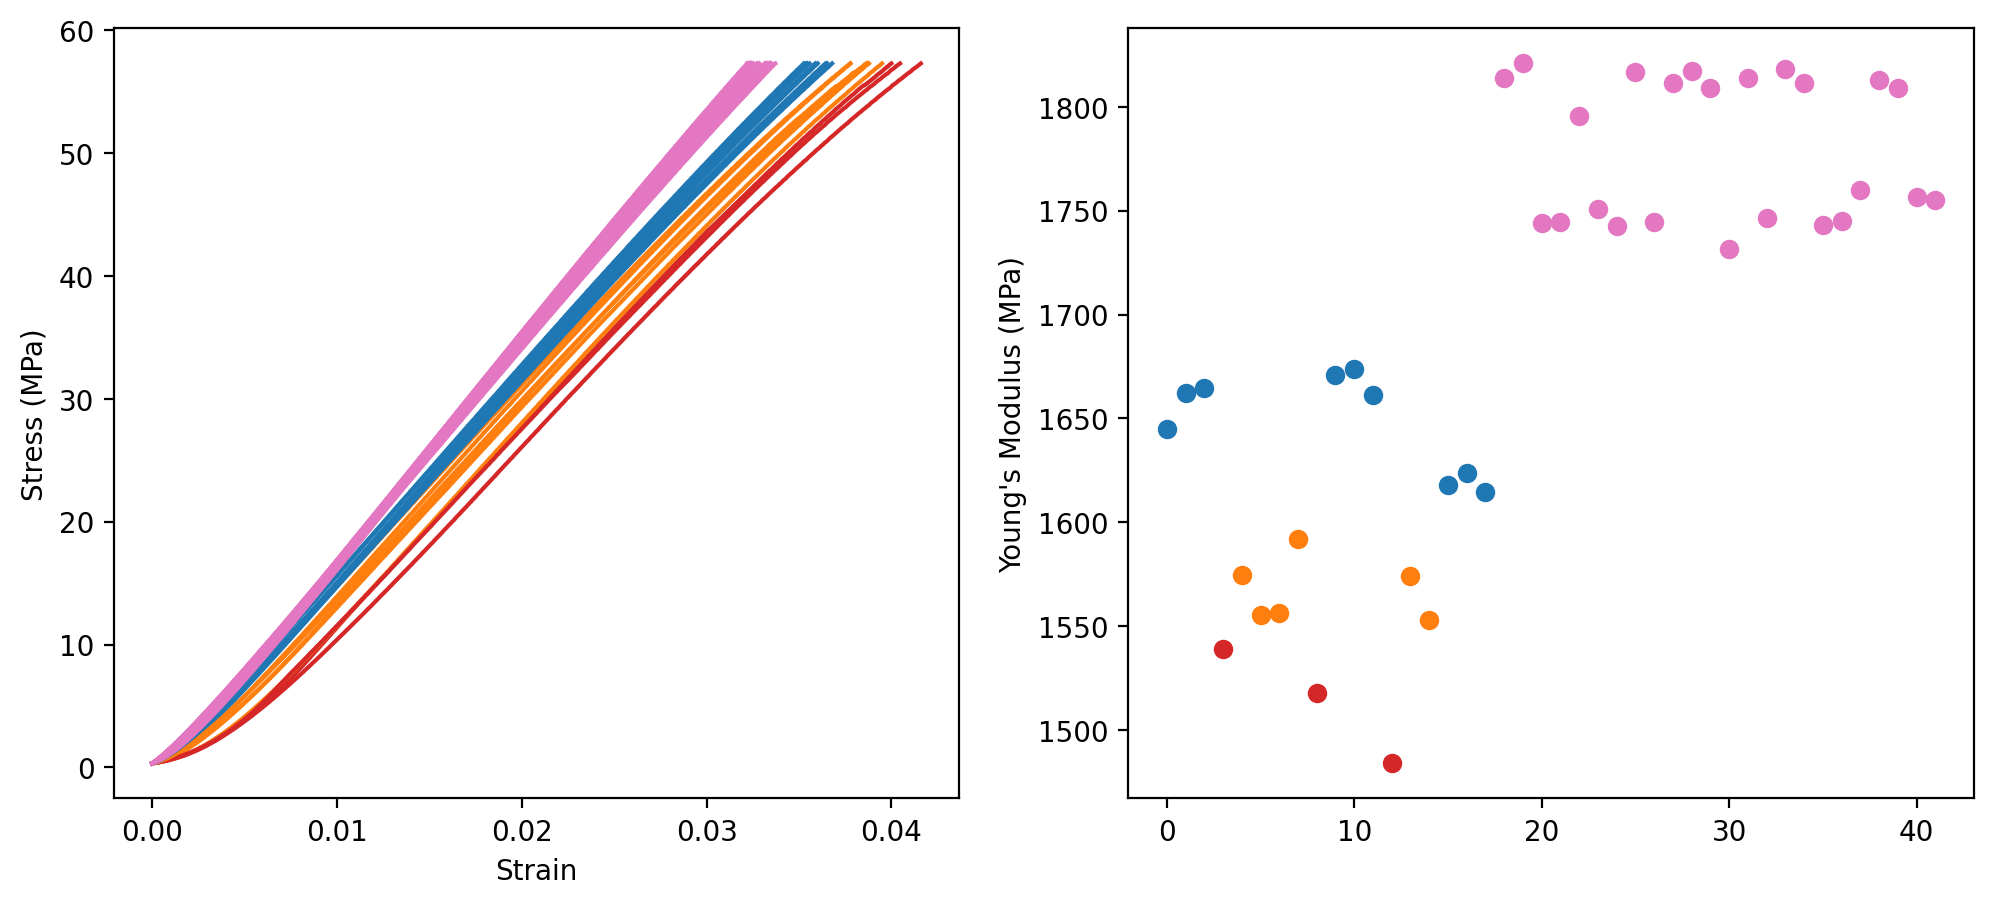

In [31]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from phd_helpers.experiments import get_instron_data

def linear_fit(x, y):
    result = linregress(x, y)
    return result.slope, result.intercept


# Range of Young's modulus values
Es = []
count = 0
# Original test #

orig_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/VeroCylinders/20251217')
glob = '**/*[HV]?_[123].csv'

nrows, ncols = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), dpi=200)


L = 20 # mm length
A = np.pi*(5**2) # mm^2 area

orient_idx = -8
c_orig = {'V':'C0', 'H': 'C1', 'H1': 'C3'}
F0 = 25*1e-3
for path in orig_path.glob(glob):
    data_raw = get_instron_data(path, False)
    data = data_raw[data_raw['force'] >= F0] # get data after initial load
    data['displacement'] -= data['displacement'].min() # reset displacement

    orient = 'H1' if path.name[orient_idx] == 'H' and path.name[-5] == '1' else path.name[orient_idx]

    x, y = data['displacement'] / L, data['force'] * 1e3 / A
    ax[0].plot(x, y, c=c_orig[orient])

    m, c = linear_fit(x, y)
    ax[1].scatter(count, m, c=c_orig[orient])
    count += 1
    Es.append(m)


# New test #

new_path = Path('../../../Experimental/LabData/materialsTesting/cylinders/vero/20260428')

c_new = {'V':'C4', 'H': 'C5'}
glob = '**/*.csv'
F0 = 25*1e-3
for path in new_path.glob(glob):
    data_raw = get_instron_data(path, False)
    data = data_raw[data_raw['force'] >= F0] # get data after initial load
    data['displacement'] -= data['displacement'].min() # reset displacement

    #orient = path.name[orient_idx]

    x, y = data['displacement'] / L, data['force'] * 1e3 / A
    ax[0].plot(x, y, c='C6')

    m, c = linear_fit(x, y)
    ax[1].scatter(count, m, c='C6')
    count += 1
    Es.append(m)

ax[0].set_xlabel('Strain')
ax[0].set_ylabel('Stress (MPa)')


#ax[1].scatter(np.arange(len(Es)), Es)
ax[1].set_ylabel("Young's Modulus (MPa)" )
plt.show()

#### Elastico properties: $\nu$ = [0.45, 0.5] ; C10 = [0.085, 0.11]

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# get data

e50_path = Path('../../../Experimental/LabData/materialsTesting/cylinders/elastico/20260427')

F0 = 0.5 # (N) initial seating load
dN = 10 # (mm) total displacement after preload applied

L0 = 20
A0 = np.pi*(5**2) # mm^2

orientations = ['Vertical', 'Horizontal']

e50 = []
for orient in orientations:
    glob = f'**/{orient[0]}.*/*.csv'
    for path in e50_path.glob(glob):
        sample_repeat = path.with_suffix('').name # e.g. 1_3 (sample 1 repeat 3)
        s, r = sample_repeat.split('_')

        data_raw = get_instron_data(path, False)
        data_raw['force'] *= 1e3 # convert from kN to N
        data = data_raw[data_raw['force'] >= F0] # get data after initial load
        data['displacement'] -= data['displacement'].min() # reset displacement
        data = data[data['displacement'] <= dN] # clip excess

        data['strain'] = data['displacement'] / L0
        data['stress'] = data['force'] / A0 # MPa

        data['orient'] = np.full(len(data), orient)
        data['sample'] = np.full(len(data), int(s))
        data['repeat'] = np.full(len(data), int(r))

        e50.append(data)
        
df = pd.concat(e50).sort_values(['orient', 'sample', 'repeat', 'time'], ascending=True).reset_index(drop=True)

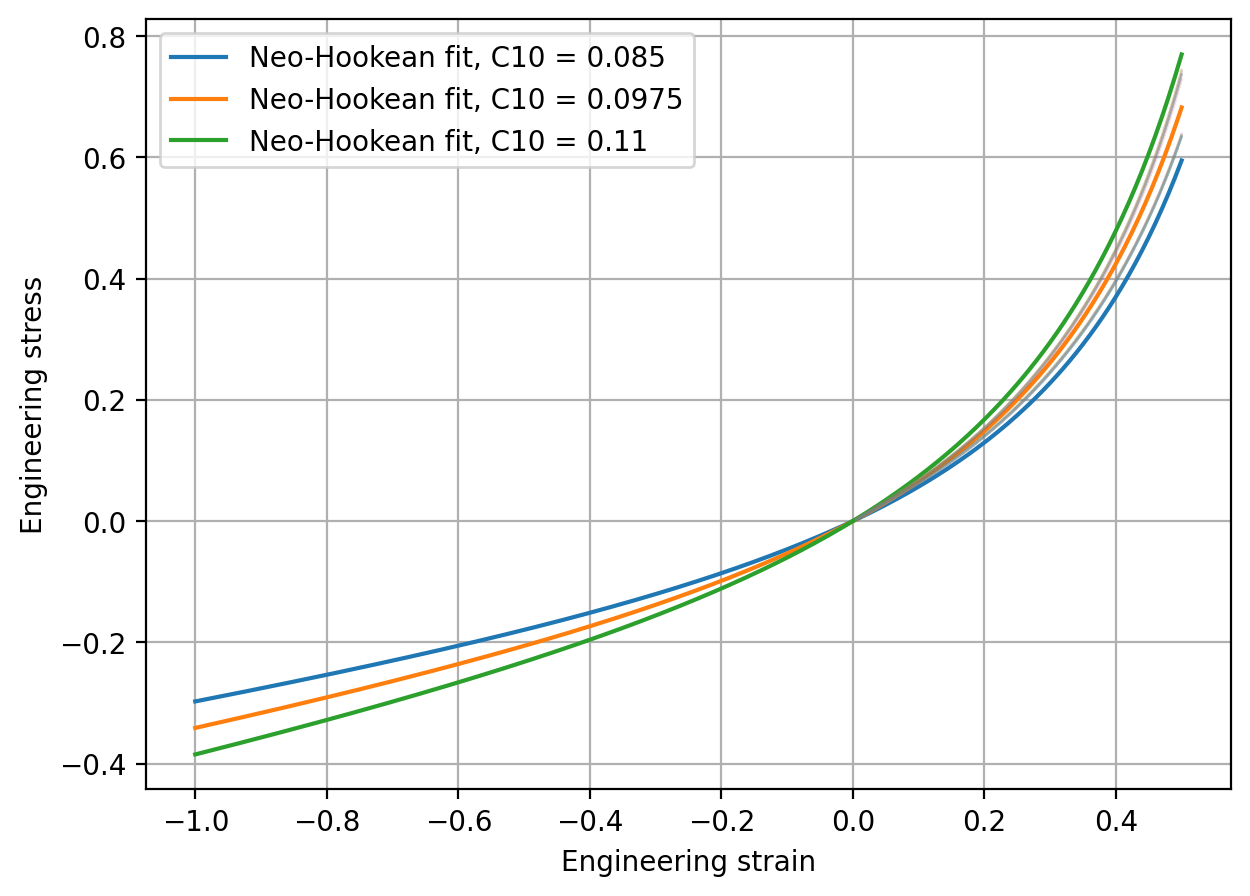

In [152]:
group_cols = ["orient", "sample", "repeat"]

df_fit = df.copy()

# Zero stress separately for each test curve
df_fit["stress_zeroed"] = (
    df_fit["stress"]
    - df_fit.groupby(group_cols)["stress"].transform("first")
)

# Optional: remove the very beginning if contact/preload effects dominate
df_fit = df_fit[df_fit["strain"] > 0.005].copy()

# Compression stretch
df_fit["lambda"] = 1.0 - df_fit["strain"]

# Neo-Hookean compression predictor:
# stress = mu * (lambda^-2 - lambda)
df_fit["x"] = df_fit["lambda"]**(-2) - df_fit["lambda"]

# Keep only valid data
df_fit = df_fit.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["stress_zeroed", "x"]
)

# Least-squares fit for one global mu
x = df_fit["x"].to_numpy()
y = df_fit["stress_zeroed"].to_numpy()

mu = np.sum(x * y) / np.sum(x**2)
C10 = mu / 2

nu = 0.45 # poisson's ratio
K = 2 * mu * (1 + nu) / (3 * (1 - 2 * nu))
D1 = 2 / K

#print(f" mu = {mu:.6g}")
#print(f"C10 = {C10:.6g}")
#print(f"K   = {K:.6g}")
#print(f"D1  = {D1:.6g}")

#PLOT#
fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=200)

strain_curve = np.linspace(-1, df_fit["strain"].max(), 300)
lambda_curve = 1.0 - strain_curve

for m in [0.17, 0.195, 0.22]:
    stress_curve = m * (lambda_curve**(-2) - lambda_curve)
    # Neo-Hookean curve
    ax.plot(strain_curve, stress_curve, linewidth=1.5, label=f"Neo-Hookean fit, C10 = {m/2:.4g}")

# Raw data
for name, g in df_fit.groupby(group_cols):
    ax.plot(g["strain"], g["stress_zeroed"], alpha=0.15, linewidth=0.8)

ax.set_xlabel("Engineering strain")
ax.set_ylabel("Engineering stress")
ax.legend()
ax.grid(True)
plt.show()

# Study 2
 - Try Ogden fit that fits compression data well but result in different tension behaviour 
    - Aim for around 400% extension at about 3-5MPa , to match data sheet

#### OGDEN

Neo-Hookean mu  = 0.20181
Neo-Hookean C10 = 0.100905

Tension scale = 4.0
Initial shear modulus sum(mu_i) = 0.20220983
Ogden parameters:
  mu1 = 0.20220983, alpha1 = 3.1960499,

Tension scale = 0.25
Initial shear modulus sum(mu_i) = 0.17860625
Ogden parameters:
  mu1 = 0.17860625, alpha1 = 0.27939656,


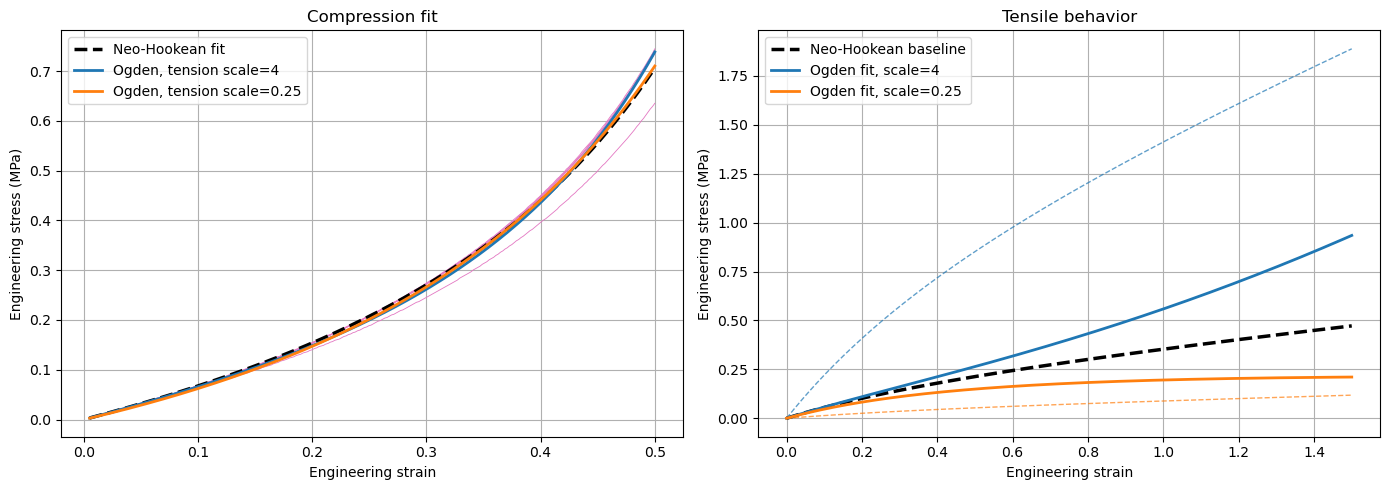

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import least_squares

# ============================================================
# USER SETTINGS
# ============================================================

group_cols = ["orient", "sample", "repeat"]

compression_strain_min = 0.005
compression_strain_max = 0.50
n_compression_points = 250

N_OGDEN = 1

tension_strain_max = 0.50
n_tension_points = 250
tension_scales = [4.0, 0.25]

compression_weight = 5.0
tension_weight = 1.0

poisson_ratio = None # None for incompressible

# ============================================================
# PREPARE COMPRESSION DATA
# ============================================================

strain_grid = np.linspace(compression_strain_min, compression_strain_max, n_compression_points)
curves = []

for name, g in df.groupby(group_cols):
    g = g.sort_values("strain").copy()

    g["stress_zeroed"] = g["stress"] - g["stress"].iloc[0]

    if g["strain"].min() <= compression_strain_min and g["strain"].max() >= compression_strain_max:
        f = interp1d(g["strain"], g["stress_zeroed"], bounds_error=False, fill_value=np.nan)

        curves.append(pd.DataFrame({
            "strain": strain_grid,
            "stress": f(strain_grid),
            "orient": name[0],
            "sample": name[1],
            "repeat": name[2],
        }))

df_comp = pd.concat(curves, ignore_index=True).dropna(subset=["strain", "stress"])

# ============================================================
# NEO-HOOKEAN FIT FROM COMPRESSION
# ============================================================

eps_c = df_comp["strain"].to_numpy()
sig_c = df_comp["stress"].to_numpy()

lam_c = 1.0 - eps_c
x_c = lam_c ** -2.0 - lam_c

mu_NH = np.sum(x_c * sig_c) / np.sum(x_c ** 2)

print(f"Neo-Hookean mu  = {mu_NH:.6g}")
print(f"Neo-Hookean C10 = {mu_NH / 2.0:.6g}")

# ============================================================
# OGDEN FIT
# ============================================================

def ogden_P(lam, p):
    P = np.zeros_like(lam, dtype=float)
    for mu, alpha in zip(p[0::2], p[1::2]):
        P += (2.0 * mu / alpha) * (
            lam ** (alpha - 1.0)
            - lam ** (-alpha / 2.0 - 1.0)
        )
    return P

eps_t = np.linspace(0.0, tension_strain_max, n_tension_points)
lam_t = 1.0 + eps_t

if N_OGDEN == 1:
    p0 = np.array([mu_NH, 2.0])
elif N_OGDEN == 2:
    p0 = np.array([0.70 * mu_NH, 2.0, 0.30 * mu_NH, -2.0])
elif N_OGDEN == 3:
    p0 = np.array([0.50 * mu_NH, 2.0, 0.30 * mu_NH, -2.0, 0.20 * mu_NH, 6.0])


lb = np.tile([-20.0 * abs(mu_NH), -20.0], N_OGDEN)
ub = np.tile([ 20.0 * abs(mu_NH),  20.0], N_OGDEN)

fit_results = []

for scale in tension_scales:
    sig_t = scale * mu_NH * (lam_t - lam_t ** -2.0)

    def resid(p):
        return np.r_[
            compression_weight * (-ogden_P(1.0 - eps_c, p) - sig_c),
            tension_weight * ( ogden_P(lam_t, p) - sig_t),
            1e-5 * p
        ]

    result = least_squares(resid, p0, bounds=(lb, ub), max_nfev=50000, xtol=1e-10, ftol=1e-10, gtol=1e-10)

    p = result.x
    mu_terms = p[0::2]
    alpha_terms = p[1::2]
    mu_initial = np.sum(mu_terms)

    if poisson_ratio == None:
        incompressible = True
        K = np.inf
        D_terms = [None] * N_OGDEN

    else:
        incompressible = False
        K = 2.0 * mu_initial * (1.0 + poisson_ratio) / (
            3.0 * (1.0 - 2.0 * poisson_ratio)
        )

        D_terms = np.zeros(N_OGDEN)
        D_terms[0] = 2.0 / K

    fit_results.append({
        "scale": scale,
        "params": p,
        "D_terms": D_terms,
        "K": K,
        "mu_initial": mu_initial,
    })

    print("\n" + "=" * 70)
    print(f"Tension scale = {scale}")
    print(f"Initial shear modulus sum(mu_i) = {mu_initial:.8g}")

    print("Ogden parameters:")
    for i in range(N_OGDEN):
        if incompressible:
            print(
                f"  mu{i+1} = {mu_terms[i]:.8g}, "
                f"alpha{i+1} = {alpha_terms[i]:.8g},"
            )
        else:
            print(
                f"  mu{i+1} = {mu_terms[i]:.8g}, "
                f"alpha{i+1} = {alpha_terms[i]:.8g}, "
                f"D{i+1} = {D_terms[i]:.8g}"
            )

# ============================================================
# PLOTTING
# ============================================================

eps_c_plot = np.linspace(compression_strain_min, compression_strain_max, 300)
eps_t_plot = np.linspace(0.0, 1.5, 300)

neo_c_plot = mu_NH * ((1.0 - eps_c_plot) ** -2.0 - (1.0 - eps_c_plot))
neo_t_plot = mu_NH * ((1.0 + eps_t_plot) - (1.0 + eps_t_plot) ** -2.0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Compression: experimental data
for _, g in df_comp.groupby(group_cols):
    ax[0].plot(g["strain"], g["stress"], linewidth=0.6, alpha=1, c='C6')

# Baselines
ax[0].plot(eps_c_plot,neo_c_plot,linestyle="--",linewidth=2.5,color="black",label="Neo-Hookean fit")
ax[1].plot(eps_t_plot,neo_t_plot,linestyle="--",linewidth=2.5,color="black",label="Neo-Hookean baseline")

# Ogden sensitivity curves
for i, res in enumerate(fit_results):
    scale = res["scale"]

    ax[0].plot(eps_c_plot,-ogden_P(1.0 - eps_c_plot, res["params"]),linewidth=2,label=f"Ogden, tension scale={scale:g}", c=f'C{i}')
    ax[1].plot(eps_t_plot,ogden_P(1.0 + eps_t_plot, res["params"]),linewidth=2,label=f"Ogden fit, scale={scale:g}", c=f'C{i}')

    ax[1].plot(
        eps_t_plot,
        scale * mu_NH * ((1.0 + eps_t_plot) - (1.0 + eps_t_plot) ** -2.0),
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        c=f'C{i}'
    )

# Formatting
ax[0].set_title("Compression fit")
ax[1].set_title("Tensile behavior")

for ax_i in ax:
    ax_i.set_xlabel("Engineering strain")
    ax_i.set_ylabel("Engineering stress (MPa)")
    ax_i.grid(True)
    ax_i.legend()

fig.tight_layout()
plt.show()

In [ ]:
make script that takes in chosen neo-hookean c10 and set c10s to the ones used above that cover experimental data (or more justified ones)
then set tension data to something sensible and get fits that keep tension constant and vary compression 

If not then have to rely on current results and argue that because change in tension with constant compression didn't matter
then it was the compressive change in the two c10 runs that made the difference...


# Polynomial fits

Input Neo-Hookean C10 = 0.15
Input Neo-Hookean mu  = 0.3

Tension scale = 4.0
Model = Reduced Polynomial, N = 3
Initial shear modulus = 0.30882019
Polynomial parameters:
  C10 = 0.15441009
  C20 = -0.0035632408
  C30 = 0.00091481835

Tension scale = 0.43
Model = Reduced Polynomial, N = 3
Initial shear modulus = 0.28895787
Polynomial parameters:
  C10 = 0.14447893
  C20 = 0.0050482007
  C30 = -0.0015067814


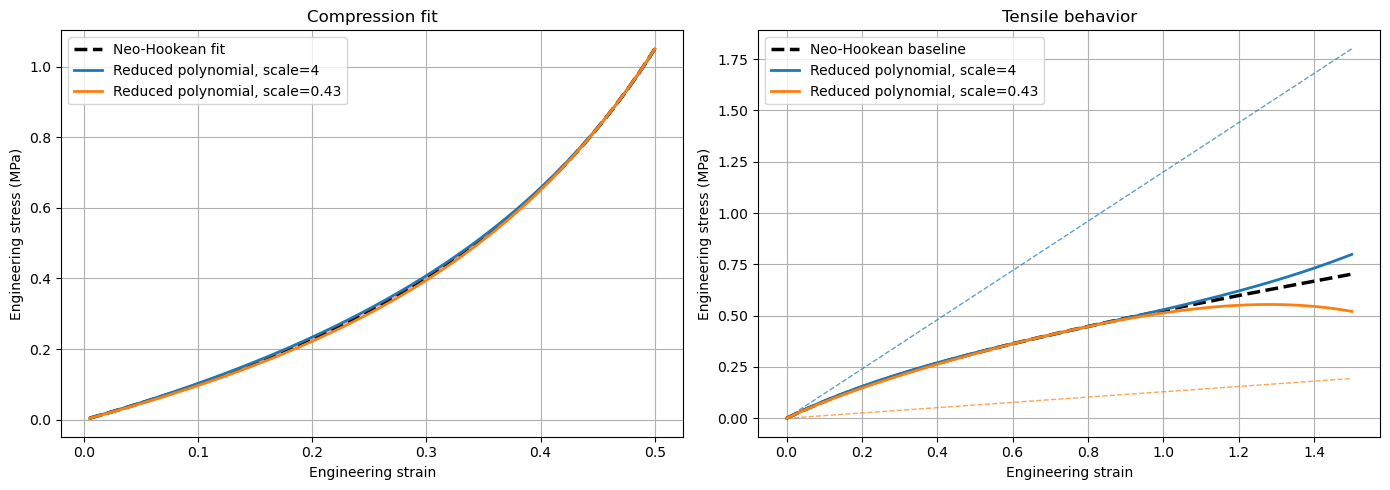

In [184]:
# ============================================================
# USER SETTINGS
# ============================================================

group_cols = ["orient", "sample", "repeat"]

compression_strain_min = 0.005
compression_strain_max = 0.50
n_compression_points = 250

poly_model = "reduced"       # "full" or "reduced"
N_POLY = 3

tension_strain_max = 0.50
n_tension_points = 250
tension_scales = [4.0, 0.43]

compression_weight = 5.0
tension_weight = 1.0

poisson_ratio = None      # None for incompressible

C10_input = 0.15          # supplied Neo-Hookean C10
mu_NH = 2.0 * C10_input

print(f"Input Neo-Hookean C10 = {C10_input:.6g}")
print(f"Input Neo-Hookean mu  = {mu_NH:.6g}")

# ============================================================
# SYNTHETIC COMPRESSION DATA FROM NEO-HOOKEAN MODEL
# ============================================================

eps_c = np.linspace(
    compression_strain_min,
    compression_strain_max,
    n_compression_points
)

lam_c = 1.0 - eps_c
sig_c = mu_NH * (lam_c ** -2.0 - lam_c)

df_comp = pd.DataFrame({
    "strain": eps_c,
    "stress": sig_c,
    "orient": "NeoHookean",
    "sample": 1,
    "repeat": 1,
})

# ============================================================
# POLYNOMIAL / REDUCED POLYNOMIAL FIT
# ============================================================

eps_t = np.linspace(0.0, tension_strain_max, n_tension_points)
lam_t = 1.0 + eps_t


def get_terms(model, N):
    if model == "reduced":
        return [(i, 0) for i in range(1, N + 1)]

    if model == "full":
        return [
            (i, j)
            for n in range(1, N + 1)
            for i in range(n, -1, -1)
            for j in [n - i]
        ]

    raise ValueError("poly_model must be 'full' or 'reduced'")


terms = get_terms(poly_model, N_POLY)


def invariants(lam):
    I1 = lam**2 + 2.0 * lam**-1
    I2 = 2.0 * lam + lam**-2
    return I1, I2


def poly_W(lam, C):
    I1, I2 = invariants(lam)
    W = np.zeros_like(lam, dtype=float)

    for c, (i, j) in zip(C, terms):
        W += c * (I1 - 3.0)**i * (I2 - 3.0)**j

    return W


def poly_P(lam, C):
    h = 1e-6
    return (poly_W(lam + h, C) - poly_W(lam - h, C)) / (2.0 * h)


def initial_mu(C):
    if poly_model == "reduced":
        C10 = C[0]
        C01 = 0.0
    else:
        C10 = C[terms.index((1, 0))] if (1, 0) in terms else 0.0
        C01 = C[terms.index((0, 1))] if (0, 1) in terms else 0.0

    return 2.0 * (C10 + C01)


def D_terms_from_mu(mu_initial):
    if poisson_ratio is None:
        return [None] * N_POLY, np.inf, True

    K = 2.0 * mu_initial * (1.0 + poisson_ratio) / (
        3.0 * (1.0 - 2.0 * poisson_ratio)
    )

    D_terms = np.zeros(N_POLY)
    D_terms[0] = 2.0 / K

    return D_terms, K, False


C0 = np.zeros(len(terms))

if (1, 0) in terms:
    C0[terms.index((1, 0))] = mu_NH / 2.0

if poly_model == "full" and (0, 1) in terms:
    C0[terms.index((0, 1))] = 0.0

fit_results = []

for scale in tension_scales:
    sig_t = scale * mu_NH * eps_t

    def resid(C):
        return np.r_[
            compression_weight * (-poly_P(1.0 - eps_c, C) - sig_c),
            tension_weight * ( poly_P(lam_t, C) - sig_t),
            1e-6 * C
        ]

    result = least_squares(
        resid,
        C0,
        max_nfev=50000,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10
    )

    C = result.x
    mu_initial = initial_mu(C)
    D_terms, K, incompressible = D_terms_from_mu(mu_initial)

    fit_results.append({
        "scale": scale,
        "params": C,
        "D_terms": D_terms,
        "K": K,
        "mu_initial": mu_initial,
    })

    print("\n" + "=" * 70)
    print(f"Tension scale = {scale}")
    print(f"Model = {poly_model.capitalize()} Polynomial, N = {N_POLY}")
    print(f"Initial shear modulus = {mu_initial:.8g}")

    if not incompressible:
        print(f"K = {K:.8g}")

    print("Polynomial parameters:")

    for c, (i, j) in zip(C, terms):
        print(f"  C{i}{j} = {c:.8g}")

    if not incompressible:
        print("D parameters:")
        for i, d in enumerate(D_terms, start=1):
            print(f"  D{i} = {d:.8g}")


# ============================================================
# PLOTTING
# ============================================================

eps_c_plot = np.linspace(compression_strain_min, compression_strain_max, 300)
eps_t_plot = np.linspace(0.0, 1.5, 300)

neo_c_plot = mu_NH * ((1.0 - eps_c_plot) ** -2.0 - (1.0 - eps_c_plot))
neo_t_plot = mu_NH * ((1.0 + eps_t_plot) - (1.0 + eps_t_plot) ** -2.0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for _, g in df_comp.groupby(group_cols):
    ax[0].plot(g["strain"], g["stress"], linewidth=0.6, alpha=1, c="C6")

ax[0].plot(
    eps_c_plot,
    neo_c_plot,
    linestyle="--",
    linewidth=2.5,
    color="black",
    label="Neo-Hookean fit"
)

ax[1].plot(
    eps_t_plot,
    neo_t_plot,
    linestyle="--",
    linewidth=2.5,
    color="black",
    label="Neo-Hookean baseline"
)

for i, res in enumerate(fit_results):
    scale = res["scale"]
    C = res["params"]

    ax[0].plot(
        eps_c_plot,
        -poly_P(1.0 - eps_c_plot, C),
        linewidth=2,
        label=f"{poly_model.capitalize()} polynomial, scale={scale:g}",
        c=f"C{i}"
    )

    ax[1].plot(
        eps_t_plot,
        poly_P(1.0 + eps_t_plot, C),
        linewidth=2,
        label=f"{poly_model.capitalize()} polynomial, scale={scale:g}",
        c=f"C{i}"
    )

    ax[1].plot(
        eps_t_plot,
        scale * mu_NH * eps_t_plot,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        c=f"C{i}"
    )

ax[0].set_title("Compression fit")
ax[1].set_title("Tensile behavior")

for ax_i in ax:
    ax_i.set_xlabel("Engineering strain")
    ax_i.set_ylabel("Engineering stress (MPa)")
    ax_i.grid(True)
    ax_i.legend()

fig.tight_layout()
plt.show()